In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import tkinter
from tkinter import filedialog
import os
from scipy.interpolate import make_interp_spline

In [18]:
root = tkinter.Tk()
root.withdraw()

dir = tkinter.filedialog.askdirectory()

dir_list = os.listdir(dir)
dir_array = np.array(dir_list)
#print(dir_array)

file_list = dir_array[np.char.endswith(dir_array,'.csv') & ~np.char.startswith(dir_array, 'output') & (dir_array != 'Decoder_trinuc_all_sets.csv') & ~np.char.endswith(dir_array,'Unblinded.csv') & ~np.char.endswith(dir_array,'Organized.csv')]

#coloc_list = coloc_list[np.char.startswith(coloc_list,'img')]
#coloc_list = coloc_list[np.char.startswith(coloc_list,"MAX_")] #May need to change or omit this line depending on the naming of the images.

print(file_list)

['Seg_Sox9_Stitched-L38102-10_V1_488-Sox9_594_NeuN_647-Olig2_30X_section1.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-10_V1_488-Sox9_594_NeuN_647-Olig2_30X_section2.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-10_V1_488-Sox9_594_NeuN_647-Olig2_30X_section3.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-11_V1_488-Sox9_594_NeuN_647-Olig2_30X_section1_Cy.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-11_V1_488-Sox9_594_NeuN_647-Olig2_30X_section2.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-11_V1_488-Sox9_594_NeuN_647-Olig2_30X_section3.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-3_V1_488-Sox9_594_NeuN_647-Olig2_30X_section1.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-3_V1_488-Sox9_594_NeuN_647-Olig2_30X_section2.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-3_V1_488-Sox9_594_NeuN_647-Olig2_30X_section3.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-4_V1_488-Sox9_594_NeuN_647-Olig2_30X_section1.tif_rotated.tif.csv'
 'Seg_Sox9_Stitched-L38102-4_V1_488-Sox9_594_NeuN_6

This code will be used to iterate through the csv files and generate a dataframe of frequency counts that has been decoded for genotype and animal. 

1098.364
Seg_Sox9_Stitched-L38102-10_V1_488-Sox9_594_NeuN_647-Olig2_30X_section1.tif_rotated.tif.csv
L38102-10
1098.932
Seg_Sox9_Stitched-L38102-10_V1_488-Sox9_594_NeuN_647-Olig2_30X_section2.tif_rotated.tif.csv
L38102-10
1098.357
Seg_Sox9_Stitched-L38102-10_V1_488-Sox9_594_NeuN_647-Olig2_30X_section3.tif_rotated.tif.csv
L38102-10
1098.643
Seg_Sox9_Stitched-L38102-11_V1_488-Sox9_594_NeuN_647-Olig2_30X_section1_Cy.tif_rotated.tif.csv
L38102-11
1098.25
Seg_Sox9_Stitched-L38102-11_V1_488-Sox9_594_NeuN_647-Olig2_30X_section2.tif_rotated.tif.csv
L38102-11
1098.413
Seg_Sox9_Stitched-L38102-11_V1_488-Sox9_594_NeuN_647-Olig2_30X_section3.tif_rotated.tif.csv
L38102-11
1098.765
Seg_Sox9_Stitched-L38102-3_V1_488-Sox9_594_NeuN_647-Olig2_30X_section1.tif_rotated.tif.csv
L38102-3
1098.288
Seg_Sox9_Stitched-L38102-3_V1_488-Sox9_594_NeuN_647-Olig2_30X_section2.tif_rotated.tif.csv
L38102-3
1098.384
Seg_Sox9_Stitched-L38102-3_V1_488-Sox9_594_NeuN_647-Olig2_30X_section3.tif_rotated.tif.csv
L38102-3
1098.

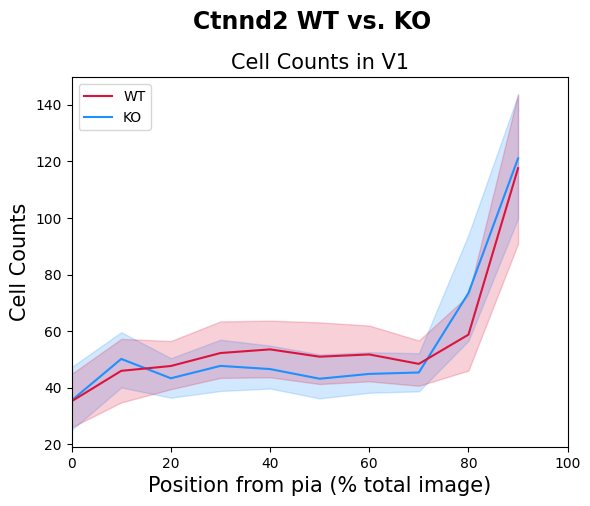

In [20]:
n=0
for i in file_list:
    current_filepath = dir+"/"+i #saves the filepath for the synapse data you will be analyzing
    #Image_dim = pd.read_csv(dir+"/"+"FOV-Area-Dim.csv") #reads a csv file in the same folder as your synapse data with the dimensions of each image
    decode = pd.read_csv(dir+"/"+"Decoder_trinuc_all_sets.csv") # 
    
    #height_dict = {}
    #rang = range(Image_dim.Label.size) #creates a range by getting the number of images you analyzed from the dimensions csv in the dir filepath
    
    decode_dict = {}
    rang_d = range(decode.new_names.size)
    
    keys = ["old_names","Animal","Sex","Genotype","Age"]

    #extract animal ID from image name
    def get_next_nine_after_pattern(input_string, pattern="Stitched-"):
        # Find the starting index of the pattern
        index = input_string.find(pattern)
        
        # Check if the pattern was found
        if index != -1:
            # Calculate the start index for the substring after the pattern
            start_index = index + len(pattern)
            
            # Find the index of the next underscore after the pattern
            underscore_index = input_string.find('_', start_index)
            
            # If the underscore is found, get the substring from the pattern to the underscore
            if underscore_index != -1:
                # Extract the string between "Stitched-" and "_"
                next_segment = input_string[start_index:underscore_index]
                
                # Check if the extracted string is less than 9 characters
                if len(next_segment) <= 6:
                    # If it's less than 9 characters, return the next 9 characters
                    return input_string[start_index: start_index + 9]
                else:
                    # If it's 9 or more characters, return the substring between "Stitched-" and "_"
                    return next_segment
        return None

            
    for y in rang_d:
        decode_dict[decode.new_names[y]] = [decode.old_names[y], decode.Animal[y], decode.Sex[y], decode.Genotype[y], decode.Age[y]]
    
    current_csv = pd.read_csv(current_filepath) #reads a csv file with the cell count data
    
    
    
    y_val = np.array(current_csv.Y[:]) #If this is for circle based, use this line.
    y_max = np.max(y_val)
    print(y_max)
    #y_val = np.array(current_csv.Y[:])#If this is for pixel based, use this line. 

    Image_ID = i #use this line of code if going straight from unet output files
    print(Image_ID)
    print (get_next_nine_after_pattern(Image_ID))
    #Image_ID = i[4:-19]+".tif" #use this line of code if image begins with "MAX_" due to preprocessing done on the image before synbot.
    
    y_val_norm = (y_val/y_max)*100
    current_hist = plt.hist(y_val_norm, bins =range(0, 110, 10), 
                            color = "white")
    plt.close()
    freq_y = current_hist[0][:]
    bins_x = current_hist[1][:current_hist[1].size-1]
    
    Image_ID_hist = np.array([i[0:-4]+".tif_rotated" for m in range(0, bins_x.size)]) #use this line of code if going straight from unet output
    #Image_ID_hist = np.array([i[4:-19]+".tif" for m in range(0, bins_x.size)]) #use this line of code if image begins with "MAX_" due to preprocessing done on the image before synbot.
    
    decode_data = decode_dict[get_next_nine_after_pattern(Image_ID)]
    decode_df_initial = pd.DataFrame(decode_data, index=keys).T
    decode_df_final = pd.concat([decode_df_initial]*bins_x.size, ignore_index = True)
    
    #line_plot = sb.lineplot(x=bins_x, y=freq_y, color = "black")
    #print("bins",bins_x.size)
    #print(Image_ID_hist)
    current_df = pd.DataFrame(Image_ID_hist,columns=["ImageID"])
    current_df["Cell Counts"]= freq_y
    current_df["Normalized distance from pia (%)"]= bins_x
    current_df = pd.concat([current_df,decode_df_final],axis=1)
    #print(current_df)
    if n == 0:
        cell_counts_df = current_df
        n = n+1
        #print(n)
    else:
        temp_list = [cell_counts_df,current_df]
        cell_counts_df = pd.concat(temp_list)
        n = n+1
        #print(n)
cell_counts_df.to_csv(dir+"/"+"Cell_Counts_Normalized_Pixel_Based_Unblinded.csv")
cell_counts_org_df = cell_counts_df.groupby(["Genotype","Animal","Normalized distance from pia (%)"]).mean("Cell Counts")
cell_counts_org_df.to_csv(dir+"/"+"Cell_Counts_Normalized_Pixel_Based_Unblinded_Organized.csv")


#Plot the data comparing WT vs KO using the animal averages at each point as the 'n' for SEM.
fig, ax = plt.subplots()
plot_final = sb.lineplot(data=cell_counts_org_df,x="Normalized distance from pia (%)",y="Cell Counts", 
                         hue = "Genotype", 
                         palette = ["dodgerblue","crimson"]
                        )

ax.set_xlim(0,100)
plt.title("Cell Counts in V1", fontsize = 15)
plt.suptitle("Ctnnd2 WT vs. KO", fontsize = 17, y = 1.02, fontweight = "bold")
plt.xlabel("Position from pia (% total image)",fontsize = 15)
plt.ylabel("Cell Counts", fontsize = 15)
handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 0]
plt.legend([handles[z] for z in order], [labels[z] for z in order])
plt.show()
        
        

This code will generate dataframes of the means and SEM for each genotype by animal to use in graphpad if you prefer to plot and run statistics that way.

In [ ]:
handles